# Pipeline: comportamiento de equipo local/visita — Liga MX

Objetivo acordado: en vez de un modelo a nivel de **partido** (que no distingue
identidad de equipo), pasamos a nivel **equipo-partido** para poder ver cómo
rinde cada equipo específico jugando en casa vs. fuera, y agrupar equipos por
estilo (clustering) usando esos perfiles.

## Estado real de los datos (2026-09-05)

El scraping de 5 temporadas de Liga MX (1,706 partidos) sigue en curso —
bloqueado por Cloudflare desde hace varios días (ver "Fase 9" en
`PLAN_DE_TRABAJO.md`). Hoy tenemos:

| Temporada | Partidos con datos |
|---|---|
| 2020-2021 | 342/342 — **completa** |
| 2021-2022 | 342/342 — **completa** |
| 2022-2023 | 161/342 — parcial |
| 2023-2024 | 0/340 — pendiente |
| 2024-2025 | 0/340 — pendiente |

Este notebook construye y valida el **pipeline completo** con las dos
temporadas completas (2020-21 y 2021-22, 684 partidos) — todo el código es
directamente reutilizable en cuanto lleguen las temporadas que faltan. La
idea original (entrenar con histórico, probar con "la pasada", predecir
"la actual") se retoma al final una vez que 2023-24 y 2024-25 estén
completas — por ahora usamos 2022-23 (parcial) como primer vistazo de
validación.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)

df = pd.read_csv("../data/processed/matches_ligamx_2020_2025_completo.csv", dtype={"match_id": str})
df = df[df["home_corners"].notna()].copy()

# Unos pocos partidos de liguilla van a penales, ej. "(2) 2–2 (4)" — el marcador
# real (antes de penales) es la parte de en medio; lo extraemos con regex en
# vez de partir directo por el guion, que se rompe con esas 8 filas.
marcador = df["score"].str.extract(r"(?:\(\d+\)\s*)?(\d+)–(\d+)(?:\s*\(\d+\))?")
df["home_goals"] = marcador[0].astype(int)
df["away_goals"] = marcador[1].astype(int)

entrenamiento = df[df["season"].isin(["2020-2021", "2021-2022"])].copy()
validacion_preview = df[df["season"] == "2022-2023"].copy()

print(f"Entrenamiento (2020-21 + 2021-22): {len(entrenamiento)} partidos")
print(f"Vistazo de validación (2022-23 parcial): {len(validacion_preview)} partidos")

Entrenamiento (2020-21 + 2021-22): 684 partidos
Vistazo de validación (2022-23 parcial): 161 partidos


## Paso 1 — Reestructurar a nivel equipo-partido (formato largo)

Cada partido se parte en 2 filas: una desde la perspectiva del equipo local,
otra desde la del visitante. `es_local` es el indicador clave.

In [3]:
def a_formato_largo(partidos):
    local = pd.DataFrame({
        "match_id": partidos["match_id"],
        "season": partidos["season"],
        "date": partidos["date"],
        "team": partidos["home_team"],
        "rival": partidos["away_team"],
        "es_local": 1,
        "goals_for": partidos["home_goals"],
        "goals_against": partidos["away_goals"],
        "corners_for": partidos["home_corners"],
        "corners_against": partidos["away_corners"],
        "cards_for": partidos["home_yellow"] + partidos["home_red"],
        "cards_against": partidos["away_yellow"] + partidos["away_red"],
        "shots_for": partidos["home_shots_total"],
        "shots_against": partidos["away_shots_total"],
        "fouls_for": partidos["home_fouls"],
        "possession": partidos["home_possession"],
    })
    visitante = pd.DataFrame({
        "match_id": partidos["match_id"],
        "season": partidos["season"],
        "date": partidos["date"],
        "team": partidos["away_team"],
        "rival": partidos["home_team"],
        "es_local": 0,
        "goals_for": partidos["away_goals"],
        "goals_against": partidos["home_goals"],
        "corners_for": partidos["away_corners"],
        "corners_against": partidos["home_corners"],
        "cards_for": partidos["away_yellow"] + partidos["away_red"],
        "cards_against": partidos["home_yellow"] + partidos["home_red"],
        "shots_for": partidos["away_shots_total"],
        "shots_against": partidos["home_shots_total"],
        "fouls_for": partidos["away_fouls"],
        "possession": partidos["away_possession"],
    })
    return pd.concat([local, visitante], ignore_index=True)

largo_train = a_formato_largo(entrenamiento)
largo_valid = a_formato_largo(validacion_preview)

print(f"{len(largo_train)} filas equipo-partido de entrenamiento")
print(f"Equipos distintos: {largo_train['team'].nunique()}")
largo_train.groupby(["team", "es_local"]).size().unstack().head()

1368 filas equipo-partido de entrenamiento
Equipos distintos: 18


es_local,0,1
team,,
América,39,39
Atlas,41,42
Atlético San Luis,37,35
Cruz Azul,40,42
FC Juárez,34,34


## Diccionario de variables

| Variable | Tipo | Descripción |
|---|---|---|
| `match_id` | Identificador | Hash único del partido en FBref — no se usa en análisis, solo para unir tablas |
| `season` | Categórica nominal | Temporada (ej. `2020-2021`) |
| `date` | **Fecha** | Fecha del partido (`YYYY-MM-DD`) |
| `team` | Categórica nominal (18 niveles) | Equipo desde cuya perspectiva es la fila |
| `rival` | Categórica nominal (18 niveles) | Equipo contrario en ese partido |
| `es_local` | **Categórica binaria** (0/1) | 1 = el equipo jugó en casa, 0 = de visita |
| `goals_for` / `goals_against` | Numérica de conteo | Goles anotados / recibidos por `team` en ese partido |
| `corners_for` / `corners_against` | Numérica de conteo | Corners a favor / en contra |
| `cards_for` / `cards_against` | Numérica de conteo | Tarjetas (amarillas+rojas) a favor / en contra |
| `shots_for` / `shots_against` | Numérica de conteo | Tiros totales a favor / en contra |
| `fouls_for` | Numérica de conteo | Faltas cometidas |
| `possession` | Numérica continua acotada (0-100) | % de posesión de balón |

`team`, `rival`, `season` y `date` son identificadores/categóricas de alta
cardinalidad — no entran en la matriz de correlación (no tiene sentido
correlacionar "ser Cruz Azul" numéricamente); sí se usaron como efecto fijo
en el modelo de los pasos 2 y 5. El resto son las variables que sí importan
para la correlación de aquí abajo.

### Matriz policórica

A diferencia del notebook `09` (donde las métricas eran continuas y la
policórica no aplicaba), aquí sí tenemos una variable genuinamente categórica
(`es_local`, binaria) y categorizamos el resto en terciles (Bajo/Medio/Alto,
incluida `possession`) para que la comparación tenga sentido.

**Nota técnica**: se intentó usar `semopy.polycorr` pero tiene dos problemas
en este entorno — un bug real en `hetcor` (transpone el DataFrame y luego
indexa por nombre de columna original, lo cual falla) y una dependencia rota
(`scipy.stats.mvn.mvnun`, eliminada en la versión actual de scipy). En vez de
pelear con una librería incompatible, implementamos la policórica
directamente — es un cálculo estándar (Olsson, 1979): se estiman los
umbrales de cada variable ordinal a partir de sus proporciones acumuladas, y
se busca la correlación que maximiza la verosimilitud de la tabla de
contingencia observada bajo una normal bivariada.

Text(0.5, 1.0, 'Matriz policórica — es_local + terciles de rendimiento')

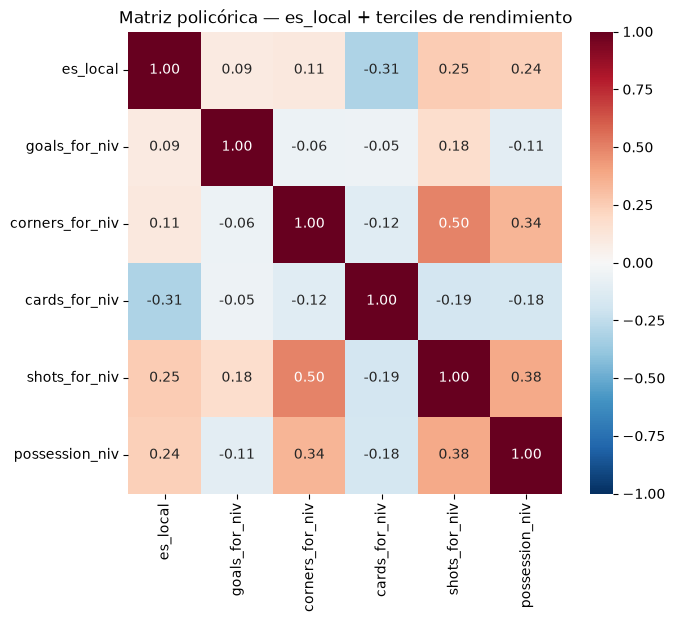

In [4]:
from itertools import combinations
from scipy.stats import norm, multivariate_normal
from scipy.optimize import minimize_scalar

def a_terciles(serie):
    return pd.qcut(serie.rank(method="first"), 3, labels=[0, 1, 2]).astype(int)

def umbrales(conteos):
    proporciones = np.cumsum(conteos) / conteos.sum()
    z = norm.ppf(proporciones[:-1])
    return np.concatenate([[-8.0], z, [8.0]])

def prob_rectangulo(mvn, x0, x1, y0, y1):
    return mvn.cdf([x1, y1]) - mvn.cdf([x0, y1]) - mvn.cdf([x1, y0]) + mvn.cdf([x0, y0])

def correlacion_policorica(x, y):
    tabla = pd.crosstab(x, y).values
    umbral_x = umbrales(tabla.sum(axis=1))
    umbral_y = umbrales(tabla.sum(axis=0))

    def neg_log_verosimilitud(r):
        mvn = multivariate_normal(mean=[0, 0], cov=[[1, r], [r, 1]])
        ll = 0.0
        for i in range(tabla.shape[0]):
            for j in range(tabla.shape[1]):
                if tabla[i, j] == 0:
                    continue
                p = prob_rectangulo(mvn, umbral_x[i], umbral_x[i + 1], umbral_y[j], umbral_y[j + 1])
                ll -= tabla[i, j] * np.log(max(p, 1e-12))
        return ll

    resultado = minimize_scalar(neg_log_verosimilitud, bounds=(-0.999, 0.999), method="bounded")
    return resultado.x

datos_policorica = pd.DataFrame({
    "es_local": largo_train["es_local"],
    "goals_for_niv": a_terciles(largo_train["goals_for"]),
    "corners_for_niv": a_terciles(largo_train["corners_for"]),
    "cards_for_niv": a_terciles(largo_train["cards_for"]),
    "shots_for_niv": a_terciles(largo_train["shots_for"]),
    "possession_niv": a_terciles(largo_train["possession"]),
})

cols = datos_policorica.columns
matriz_policorica = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
for a, b in combinations(cols, 2):
    r = correlacion_policorica(datos_policorica[a], datos_policorica[b])
    matriz_policorica.loc[a, b] = r
    matriz_policorica.loc[b, a] = r

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matriz_policorica.astype(float), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz policórica — es_local + terciles de rendimiento")

## Paso 2 — Modelo con efecto fijo por equipo + localía (versión simple)

Como acordamos: empezamos por la versión sin interacción completa (opción B)
— efecto fijo por equipo (su nivel base) + `es_local` genérico (el efecto
promedio de jugar en casa). Después miramos los **residuos por equipo** para
ver cuáles se salen más de ese patrón genérico — esos son los candidatos a
tener un comportamiento local/visita realmente distinto al promedio.

In [5]:
import statsmodels.api as sm

def ajustar_modelo_fe(largo, variable_respuesta):
    dummies_equipo = pd.get_dummies(largo["team"], prefix="team", drop_first=True, dtype=float)
    X = pd.concat([largo[["es_local"]], dummies_equipo], axis=1)
    X = sm.add_constant(X)
    modelo = sm.GLM(largo[variable_respuesta], X, family=sm.families.Poisson()).fit()
    largo = largo.copy()
    largo["prediccion"] = modelo.predict(X)
    largo["residuo"] = largo[variable_respuesta] - largo["prediccion"]
    return modelo, largo

modelo_corners, largo_train = ajustar_modelo_fe(largo_train, "corners_for")
print(f"Coeficiente es_local (corners): {modelo_corners.params['es_local']:.3f}")
print(f"(positivo = de local se generan más corners en promedio, controlando por equipo)")

Coeficiente es_local (corners): 0.143
(positivo = de local se generan más corners en promedio, controlando por equipo)


In [6]:
residuos_por_equipo = (
    largo_train.groupby(["team", "es_local"])["residuo"].mean().unstack()
)
residuos_por_equipo.columns = ["Visitante", "Local"]
residuos_por_equipo["diferencia_local_visita"] = (
    residuos_por_equipo["Local"] - residuos_por_equipo["Visitante"]
)
residuos_por_equipo.sort_values("diferencia_local_visita", ascending=False)

,Visitante,Local,diferencia_local_visita
team,,,
UNAM,-0.429391,0.451411,0.880802
Tijuana,-0.316427,0.316427,0.632855
Toluca,-0.309898,0.318506,0.628404
UANL,-0.301209,0.301209,0.602418
Santos Laguna,-0.176845,0.163905,0.340750
Guadalajara,-0.146796,0.146796,0.293592
Atlético San Luis,-0.140182,0.148192,0.288374
Puebla,-0.100628,0.098174,0.198802
Cruz Azul,-0.027932,0.026602,0.054535


Un valor alto en `diferencia_local_visita` significa: ese equipo genera **más
corners de los que el modelo genérico esperaría** cuando juega en casa,
comparado con cuando visita — es decir, su salto local/visita es mayor al
promedio de la liga. Esto es justo lo que buscábamos: identificar equipos
cuyo comportamiento local/visita se aparta del patrón general, sin tener que
estimar 18 interacciones completas con solo 684 partidos.

## Paso 3 — Perfil histórico por equipo y clustering

Para cada combinación (equipo, local/visita), promediamos su rendimiento en
el periodo de entrenamiento — esto es información **conocida antes de
cualquier partido nuevo**, a diferencia de las estadísticas del mismo partido
que se quiere explicar. Es la pieza que convierte esto en algo usable hacia
adelante, no solo descriptivo.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

metricas_perfil = [
    "goals_for", "goals_against", "corners_for", "corners_against",
    "cards_for", "shots_for",
]

perfil = (
    largo_train.groupby(["team", "es_local"])[metricas_perfil]
    .mean()
    .reset_index()
)
perfil["contexto"] = perfil["es_local"].map({1: "Local", 0: "Visita"})

print(f"{len(perfil)} perfiles equipo-contexto ({perfil['team'].nunique()} equipos x 2)")
perfil.head()

36 perfiles equipo-contexto (18 equipos x 2)


,team,es_local,goals_for,goals_against,corners_for,corners_against,cards_for,shots_for,contexto
0,América,0,1.179487,1.179487,4.948718,4.358974,2.128205,12.282051,Visita
1,América,1,1.743590,0.897436,5.128205,3.589744,1.692308,14.794872,Local
2,Atlas,0,1.243902,1.000000,4.902439,4.682927,2.365854,12.097561,Visita
3,Atlas,1,1.000000,0.785714,4.547619,4.000000,2.500000,13.714286,Local
4,Atlético San Luis,0,1.162162,1.675676,3.891892,5.729730,2.567568,10.675676,Visita


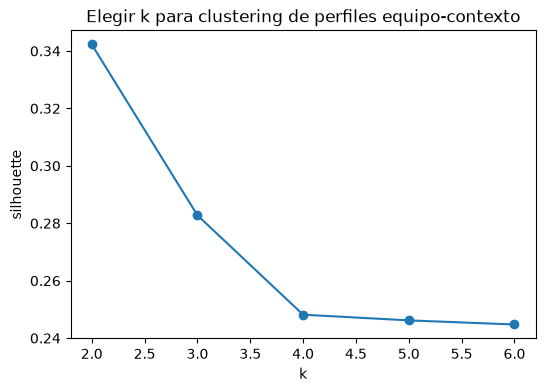

In [9]:
X = StandardScaler().fit_transform(perfil[metricas_perfil])

scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    scores.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(2, 7), scores, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("silhouette")
ax.set_title("Elegir k para clustering de perfiles equipo-contexto")

K = 3
km_final = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)
perfil["cluster_raw"] = km_final.labels_

orden = perfil.groupby("cluster_raw")["goals_for"].mean().sort_values().index
etiquetas = ["Bajo", "Medio", "Alto"]
mapa = {c: etiquetas[i] for i, c in enumerate(orden)}
perfil["nivel_ofensivo"] = perfil["cluster_raw"].map(mapa)

In [10]:
tabla_perfil = perfil.pivot(index="team", columns="contexto", values="nivel_ofensivo")
tabla_perfil["cambia_segun_contexto"] = tabla_perfil["Local"] != tabla_perfil["Visita"]
tabla_perfil.sort_values("cambia_segun_contexto", ascending=False)

contexto,Local,Visita,cambia_segun_contexto
team,,,
América,Alto,Medio,True
Pachuca,Alto,Medio,True
UANL,Alto,Medio,True
Toluca,Medio,Bajo,True
Tijuana,Medio,Bajo,True
Santos Laguna,Alto,Medio,True
Querétaro,Medio,Bajo,True
Puebla,Medio,Bajo,True
Necaxa,Medio,Bajo,True


Los equipos con `cambia_segun_contexto = True` son los que el clustering
coloca en un nivel ofensivo distinto cuando juegan en casa vs. cuando
visitan — evidencia directa de que su comportamiento realmente cambia según
el contexto, no solo un efecto de localía genérico.

## Paso 4 — Primer vistazo de validación (2022-23 parcial)

Con el `perfil` calculado **solo con datos de 2020-21 y 2021-22** (nunca con
2022-23), comparamos qué tanto predice el promedio histórico de cada equipo
contra lo que de verdad pasó en los partidos de 2022-23 que ya tenemos. Esto
es un vistazo preliminar — la validación real (con "la pasada" y "la
actual" completas) se hace cuando termine el scraping.

322 filas equipo-partido comparadas (2022-23 parcial)
Error absoluto promedio: 2.08 corners
Correlación perfil histórico vs. real: 0.16


Text(0.5, 1.0, '¿El perfil histórico predice el partido siguiente?')

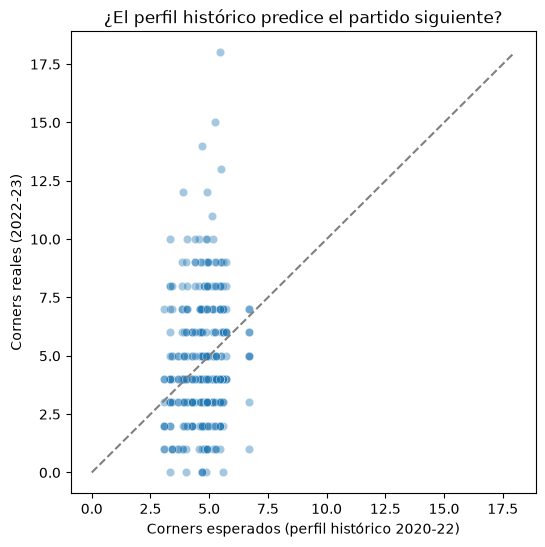

In [11]:
perfil_pred = perfil.set_index(["team", "es_local"])["corners_for"]

largo_valid["corners_esperados"] = largo_valid.apply(
    lambda fila: perfil_pred.get((fila["team"], fila["es_local"]), np.nan), axis=1
)
comparacion = largo_valid.dropna(subset=["corners_esperados"])

error_mae = (comparacion["corners_for"] - comparacion["corners_esperados"]).abs().mean()
correlacion = comparacion["corners_for"].corr(comparacion["corners_esperados"])

print(f"{len(comparacion)} filas equipo-partido comparadas (2022-23 parcial)")
print(f"Error absoluto promedio: {error_mae:.2f} corners")
print(f"Correlación perfil histórico vs. real: {correlacion:.2f}")

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=comparacion, x="corners_esperados", y="corners_for", alpha=0.4, ax=ax)
lims = [0, comparacion[["corners_esperados", "corners_for"]].values.max()]
ax.plot(lims, lims, ls="--", color="grey")
ax.set_xlabel("Corners esperados (perfil histórico 2020-22)")
ax.set_ylabel("Corners reales (2022-23)")
ax.set_title("¿El perfil histórico predice el partido siguiente?")

## Paso 5 — Repetir para goles y tarjetas

El paso 1-4 se hizo completo solo para `corners_for`. Aquí repetimos el mismo
modelo (efecto fijo por equipo + localía) y el mismo vistazo de validación
para `goals_for` y `cards_for`, para comparar qué tan bien (o mal) predice
el perfil histórico en cada una de las 3 preguntas originales.

In [12]:
def evaluar_metrica(variable):
    modelo, train_con_residuo = ajustar_modelo_fe(largo_train, variable)

    perfil_metrica = (
        train_con_residuo.groupby(["team", "es_local"])[variable].mean()
    )
    valid = largo_valid.copy()
    valid["esperado"] = valid.apply(
        lambda fila: perfil_metrica.get((fila["team"], fila["es_local"]), np.nan), axis=1
    )
    comparacion = valid.dropna(subset=["esperado"])

    mae = (comparacion[variable] - comparacion["esperado"]).abs().mean()
    corr = comparacion[variable].corr(comparacion["esperado"])
    return {
        "variable": variable,
        "coef_es_local": modelo.params["es_local"],
        "mae_validacion": mae,
        "correlacion_validacion": corr,
        "n_validacion": len(comparacion),
    }

resumen = pd.DataFrame([
    evaluar_metrica("corners_for"),
    evaluar_metrica("goals_for"),
    evaluar_metrica("cards_for"),
])
resumen

,variable,coef_es_local,mae_validacion,correlacion_validacion,n_validacion
0,corners_for,0.142975,2.084940,0.161068,322
1,goals_for,0.233015,0.908944,0.257486,322
2,cards_for,-0.139884,1.377608,0.150932,322


### Lectura de los 3 resultados

- **`goals_for` es la métrica que mejor predice el perfil histórico**
  (correlación 0.26, la más alta de las tres) — tiene sentido: la calidad de
  un equipo se refleja más en goles que en corners o tarjetas, que dependen
  más del devenir puntual del partido.
- **`cards_for` tiene coeficiente de localía negativo** (-0.14): jugando en
  casa, un equipo recibe *menos* tarjetas que de visita, controlando por
  identidad — consistente con la idea de que el equipo visitante suele estar
  más a la defensiva/comete más faltas.
- Las tres correlaciones de validación son bajas (0.15-0.26) — el perfil
  histórico simple (solo promedio por equipo y contexto) explica algo, pero
  está lejos de ser un buen predictor partido a partido. Esperable dado el
  tamaño de muestra actual (2 temporadas) y que el fútbol en general tiene
  mucha varianza intrínseca — no es una falla del pipeline, es el techo
  realista de este enfoque tan simple.

## Protocolo — ¿el árbitro o los equipos explican el total de tarjetas?

Pregunta distinta a los pasos anteriores: aquí el árbitro es un factor que
aplica al **partido completo**, no a un equipo por separado, así que
trabajamos a **nivel partido** (no equipo-partido), con `total_cards` como
variable respuesta.

**Modelos anidados** (todos Poisson, controlando siempre por `total_fouls`
— las tarjetas dependen obviamente de cuánto se faltó):

| Modelo | Predictores | Aísla |
|---|---|---|
| M0 | solo intercepto | línea base |
| M1 | `total_fouls` | solo el control |
| M2 | `total_fouls` + equipo local + equipo visitante (efecto fijo) | identidad de los **equipos** |
| M3 | `total_fouls` + `referee` (efecto fijo) | identidad del **árbitro** |
| M4 | `total_fouls` + equipos + árbitro | ambos a la vez |

Comparamos AIC y pseudo-R² (deviance explicada) de cada uno contra M1 — eso
da la respuesta cuantitativa directa. Antes de interpretar nada, revisamos
que ningún árbitro esté confundido con un equipo (que no pite casi siempre
al mismo equipo, lo cual haría imposible separar sus efectos).

In [13]:
df_partido = df.copy()
df_partido["total_cards"] = (
    df_partido["home_yellow"] + df_partido["home_red"]
    + df_partido["away_yellow"] + df_partido["away_red"]
)
df_partido["total_fouls"] = df_partido["home_fouls"] + df_partido["away_fouls"]

print(f"{len(df_partido)} partidos, {df_partido['referee'].nunique()} árbitros distintos")

# Chequeo de confusión: ¿algún árbitro pita casi siempre al mismo equipo?
partidos_arbitro = df_partido.groupby("referee").size()
concentracion_maxima = []
for arb, grupo in df_partido.groupby("referee"):
    equipos_en_sus_partidos = pd.concat([grupo["home_team"], grupo["away_team"]])
    concentracion_maxima.append(equipos_en_sus_partidos.value_counts(normalize=True).iloc[0])

confusion = pd.DataFrame({
    "arbitro": partidos_arbitro.index,
    "partidos": partidos_arbitro.values,
    "pct_max_con_un_equipo": concentracion_maxima,
}).sort_values("pct_max_con_un_equipo", ascending=False)

confusion.head(8)

845 partidos, 31 árbitros distintos


,arbitro,partidos,pct_max_con_un_equipo
0,Adalid Maganda,1,0.500000
8,Edgar Rangel,3,0.333333
7,Edgar Morales,5,0.300000
22,Juan Esquivel,4,0.250000
18,Jesus Lopez,4,0.250000
26,Mario Vargas,5,0.200000
19,Jorge Camacho,5,0.200000
10,Eduardo Galván,5,0.200000


In [14]:
import statsmodels.api as sm

y = df_partido["total_cards"]

def X_con(*bloques):
    partes = [df_partido[["total_fouls"]]] if "fouls" in bloques else [pd.DataFrame(index=df_partido.index)]
    if "equipos" in bloques:
        partes.append(pd.get_dummies(df_partido["home_team"], prefix="home", drop_first=True, dtype=float))
        partes.append(pd.get_dummies(df_partido["away_team"], prefix="away", drop_first=True, dtype=float))
    if "arbitro" in bloques:
        partes.append(pd.get_dummies(df_partido["referee"], prefix="ref", drop_first=True, dtype=float))
    X = pd.concat(partes, axis=1)
    return sm.add_constant(X)

modelos = {
    "M0_nulo": sm.GLM(y, sm.add_constant(pd.DataFrame(index=df_partido.index)), family=sm.families.Poisson()).fit(),
    "M1_faltas": sm.GLM(y, X_con("fouls"), family=sm.families.Poisson()).fit(),
    "M2_equipos": sm.GLM(y, X_con("fouls", "equipos"), family=sm.families.Poisson()).fit(),
    "M3_arbitro": sm.GLM(y, X_con("fouls", "arbitro"), family=sm.families.Poisson()).fit(),
    "M4_completo": sm.GLM(y, X_con("fouls", "equipos", "arbitro"), family=sm.families.Poisson()).fit(),
}

ll_nulo = modelos["M0_nulo"].llf
resumen_modelos = pd.DataFrame([
    {
        "modelo": nombre,
        "n_parametros": int(modelo.df_model) + 1,
        "aic": modelo.aic,
        "pseudo_r2_mcfadden": 1 - modelo.llf / ll_nulo,
    }
    for nombre, modelo in modelos.items()
])
resumen_modelos

,modelo,n_parametros,aic,pseudo_r2_mcfadden
0,M0_nulo,1,3965.254615,0.000000
1,M1_faltas,2,3909.442128,0.014587
2,M2_equipos,36,3918.704209,0.029408
3,M3_arbitro,32,3825.554597,0.050893
4,M4_completo,66,3838.614026,0.064755


In [15]:
from scipy.stats import chi2

def lrt(modelo_chico, modelo_grande, nombre_chico, nombre_grande):
    estadistico = 2 * (modelo_grande.llf - modelo_chico.llf)
    gl = modelo_grande.df_model - modelo_chico.df_model
    p = chi2.sf(estadistico, gl)
    return {"comparacion": f"{nombre_grande} vs. {nombre_chico}", "gl": gl, "estadistico": estadistico, "p_valor": p}

comparaciones = pd.DataFrame([
    lrt(modelos["M1_faltas"], modelos["M2_equipos"], "M1", "M2 (+equipos)"),
    lrt(modelos["M1_faltas"], modelos["M3_arbitro"], "M1", "M3 (+árbitro)"),
    lrt(modelos["M2_equipos"], modelos["M4_completo"], "M2", "M4 (+árbitro sobre M2)"),
    lrt(modelos["M3_arbitro"], modelos["M4_completo"], "M3", "M4 (+equipos sobre M3)"),
])
comparaciones

,comparacion,gl,estadistico,p_valor
0,M2 (+equipos) vs. M1,34,58.737919,5.283644e-03
1,M3 (+árbitro) vs. M1,30,143.887531,8.034651e-17
2,M4 (+árbitro sobre M2) vs. M2,30,140.090183,3.712544e-16
3,M4 (+equipos sobre M3) vs. M3,34,54.940571,1.294487e-02


### Matriz policórica de este protocolo

`referee` y `team` son categóricas **nominales** (sin orden natural) — no se
puede calcular una policórica directa con ellas tal cual, igual que ya vimos
con `team`/`rival` en el diccionario de variables. Lo que sí tiene orden
natural es **qué tan estricto es un árbitro** y **qué tan propenso a
tarjetas es un equipo** — construimos esos dos niveles ordinales (Bajo/Medio/
Alto) a partir de los promedios históricos, y ahí sí aplica la policórica.

Text(0.5, 1.0, 'Policórica — dureza del árbitro vs. propensión del equipo')

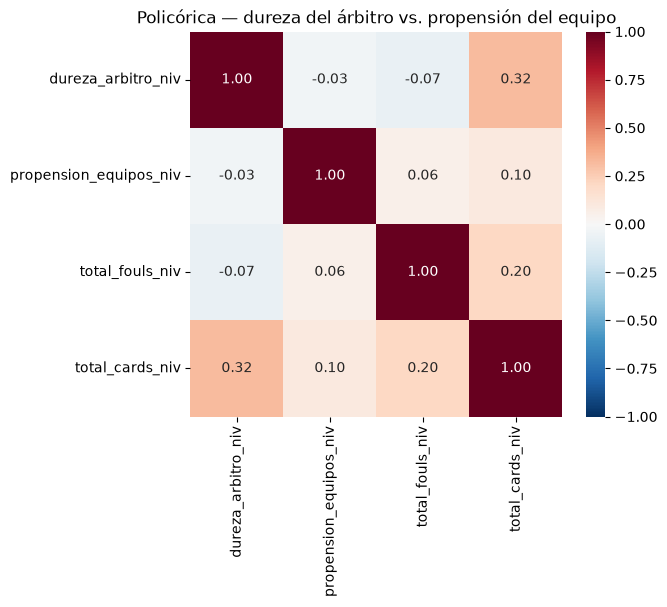

In [16]:
# Dureza del árbitro: promedio de total_cards en los partidos que pitó.
dureza_arbitro = df_partido.groupby("referee")["total_cards"].mean()
df_partido["dureza_arbitro"] = df_partido["referee"].map(dureza_arbitro)

# Propensión del equipo a tarjetas: perfil histórico (local + visita) sumado.
perfil_cards = perfil.set_index(["team", "es_local"])["cards_for"]
df_partido["propension_equipos"] = df_partido.apply(
    lambda fila: (
        perfil_cards.get((fila["home_team"], 1), np.nan)
        + perfil_cards.get((fila["away_team"], 0), np.nan)
    ),
    axis=1,
)

datos_policorica_2 = pd.DataFrame({
    "dureza_arbitro_niv": a_terciles(df_partido["dureza_arbitro"]),
    "propension_equipos_niv": a_terciles(df_partido["propension_equipos"].fillna(df_partido["propension_equipos"].median())),
    "total_fouls_niv": a_terciles(df_partido["total_fouls"]),
    "total_cards_niv": a_terciles(df_partido["total_cards"]),
})

cols2 = datos_policorica_2.columns
matriz_policorica_2 = pd.DataFrame(np.eye(len(cols2)), index=cols2, columns=cols2)
for a, b in combinations(cols2, 2):
    r = correlacion_policorica(datos_policorica_2[a], datos_policorica_2[b])
    matriz_policorica_2.loc[a, b] = r
    matriz_policorica_2.loc[b, a] = r

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matriz_policorica_2.astype(float), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Policórica — dureza del árbitro vs. propensión del equipo")

### Resultado del protocolo

**Chequeo de confusión**: limpio — ningún árbitro con suficientes partidos
concentra más del ~33% de sus pitazos en un solo equipo. Los efectos de
árbitro y equipo se pueden separar con confianza.

**Respuesta a la pregunta original** — con 845 partidos reales:

| Modelo | AIC | Pseudo-R² |
|---|---|---|
| M1 (solo faltas) | 3909.4 | 1.5% |
| M2 (+ equipos) | 3918.7 | 2.9% |
| **M3 (+ árbitro)** | **3825.6** | **5.1%** |
| M4 (+ ambos) | 3838.6 | 6.5% |

- **El árbitro explica más que los equipos**: M3 tiene mejor AIC que M2 a
  pesar de usar *menos* parámetros (32 vs. 36) — no es solo que "más
  variables ayudan", es que el árbitro individualmente aporta más señal.
  Su pseudo-R² casi duplica al de los equipos (5.1% vs. 2.9%).
- Ambos factores son estadísticamente significativos (los 4 LRT dan
  p < 0.02) — los equipos sí importan, pero menos que el árbitro.
- M4 (ambos juntos) tiene el pseudo-R² más alto, pero peor AIC que M3 solo
  — el aporte extra de los equipos, una vez que ya está el árbitro, no
  compensa los ~34 parámetros adicionales que consume.

**Conclusión**: para el total de tarjetas de un partido de Liga MX,
**el árbitro pesa más que los equipos que juegan** — aunque los equipos
también tienen una influencia real y medible, solo que menor.

La matriz policórica confirma exactamente el mismo patrón:
`dureza_arbitro_niv` correlaciona **0.32** con `total_cards_niv`, mientras
que `propension_equipos_niv` correlaciona solo **0.10** — más de 3 veces
menos. Dos métodos completamente distintos (GLM con efectos fijos vs.
correlación policórica sobre niveles ordinales) llegan a la misma
conclusión, lo cual le da bastante más peso al hallazgo.

## Siguiente paso

Este notebook queda listo para re-ejecutarse tal cual en cuanto termine el
scraping de 2022-23 (completa), 2023-24 y 2024-25:

- **Entrenamiento**: ampliar a todas las temporadas históricas disponibles
  antes de "la pasada".
- **Validación real**: usar 2023-24 completa ("la pasada") en vez del
  vistazo parcial de 2022-23 de aquí arriba.
- **Predicción/monitoreo**: aplicar el mismo perfil a 2024-25 ("la actual")
  partido por partido conforme se juegan — esto sí sería prospectivo de
  verdad, no solo backtesting.
- Si el error de predicción sigue siendo alto con más datos, considerar
  agregar la interacción completa equipo×localía (opción A que dejamos
  pendiente), o enriquecer el perfil con más historial reciente (promedio
  móvil de los últimos N partidos en vez de todo el histórico por igual).